# FASE 0: ANÁLISIS EXPLORATORIO (EDA) - VERSIÓN SIMPLIFICADA

**Objetivo:** Cargar, limpiar y generar dataset limpio SIN extracción de features nuevas

**Requisito:** Analizar dataset original tal como está - sin transformaciones de texto

In [114]:
# 1. IMPORTAR LIBRERÍAS
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [115]:
# 2. CARGAR DATOS DEL JSON
print("="*80)
print("CARGANDO DATOS DESDE JSON")
print("="*80)

with open('../Data/Datos_consolidados01.json', 'r', encoding='utf-8') as f:
    json_data = json.load(f)

records = json_data['Sheet1']
df_raw = pd.DataFrame(records)

print(f"\n✅ Registros cargados: {len(df_raw):,}")
print(f"✅ Columnas originales: {df_raw.shape[1]}")
print(f"\nColumnas disponibles:")
for i, col in enumerate(df_raw.columns, 1):
    print(f"  {i:2d}. {col}")

CARGANDO DATOS DESDE JSON

✅ Registros cargados: 17,558
✅ Columnas originales: 11

Columnas disponibles:
   1. Fecha de inicio
   2. Fecha de creación
   3. Descripción
   4. Producto
   5. Tipo de trabajo: Nombre de tipo de trabajo
   6. Tipo de Cliente
   7. Servicio Múltiple
   8. Servicio urgente
   9. Crítico
  10. Fuente
  11. Habeas Data


In [116]:
# 3. RENOMBRAR COLUMNAS Y PREPARAR DATOS
df = df_raw.copy()

column_mapping = {
    'Fecha de inicio': 'fecha_inicio',
    'Fecha de creación': 'fecha_creacion',
    'Descripción': 'descripcion',
    'Producto': 'producto',
    'Tipo de trabajo: Nombre de tipo de trabajo': 'tipo_trabajo',
    'Tipo de Cliente': 'tipo_cliente',
    'Servicio Múltiple': 'servicio_multiple',
    'Servicio urgente': 'servicio_urgente',
    'Crítico': 'critico',
    'Fuente': 'fuente',
    'Habeas Data': 'habeas_data'
}

df.rename(columns=column_mapping, inplace=True)
print(f"\n✅ Columnas renombradas correctamente\n")

# Mostrar información básica
print("="*80)
print("INFORMACIÓN DEL DATASET ORIGINAL")
print("="*80)
print(f"\nDimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\nValores faltantes (NaN):")
print(df.isnull().sum())


✅ Columnas renombradas correctamente

INFORMACIÓN DEL DATASET ORIGINAL

Dimensiones: 17,558 filas × 11 columnas

Valores faltantes (NaN):
fecha_inicio           0
fecha_creacion         0
descripcion            0
producto               0
tipo_trabajo           0
tipo_cliente          17
servicio_multiple      0
servicio_urgente       0
critico                0
fuente               123
habeas_data            0
dtype: int64


In [117]:
# 4. EXPLORACIÓN DE DATOS ORIGINALES (SIN TRANSFORMACIONES)
print("\n" + "="*80)
print("EXPLORACIÓN DE VARIABLES ORIGINALES")
print("="*80)

print("\n📊 VARIABLES CATEGÓRICAS:")
categóricas = ['producto', 'tipo_trabajo', 'tipo_cliente', 'fuente', 'habeas_data']
for col in categóricas:
    unique_count = df[col].nunique()
    print(f"\n  {col}: {unique_count} valores únicos")
    if unique_count <= 5:
        print(f"    Valores: {df[col].value_counts().to_dict()}")

print("\n\n📊 VARIABLES BOOLEANAS:")
booleanas = ['servicio_multiple', 'servicio_urgente', 'critico']
for col in booleanas:
    counts = df[col].value_counts()
    print(f"\n  {col}:")
    for val, count in counts.items():
        print(f"    {val}: {count:,} ({count/len(df)*100:.2f}%)")


EXPLORACIÓN DE VARIABLES ORIGINALES

📊 VARIABLES CATEGÓRICAS:

  producto: 1041 valores únicos

  tipo_trabajo: 93 valores únicos

  tipo_cliente: 3 valores únicos
    Valores: {'No Aplica': 11377, 'Reincidente': 5083, 'Frecuente': 1081}

  fuente: 13 valores únicos

  habeas_data: 2 valores únicos
    Valores: {'SI': 11594, 'NO': 5964}


📊 VARIABLES BOOLEANAS:

  servicio_multiple:
    False: 16,309 (92.89%)
    True: 1,249 (7.11%)

  servicio_urgente:
    False: 16,909 (96.30%)
    True: 649 (3.70%)

  critico:
    False: 17,552 (99.97%)
    True: 6 (0.03%)


In [118]:
# 5. IMPUTACIÓN INTELIGENTE DE NaN
print("\n" + "="*80)
print("IMPUTACIÓN DE VALORES FALTANTES")
print("="*80)

df_clean = df.copy()

# Registrar imputaciones
imputaciones = {}

for col in df_clean.columns:
    nan_count = df_clean[col].isnull().sum()
    if nan_count > 0:
        modo = df_clean[col].mode()[0] if not df_clean[col].mode().empty else 'Unknown'
        df_clean[col].fillna(modo, inplace=True)
        imputaciones[col] = {'nan_count': nan_count, 'imputed_with': str(modo)}
        print(f"\n✅ {col}:")
        print(f"   NaN encontrados: {nan_count}")
        print(f"   Imputado con: '{modo}'")

# Validación
total_nan_final = df_clean.isnull().sum().sum()
print(f"\n\n🔍 Validación final:")
print(f"   Total NaN en dataset: {total_nan_final}")
if total_nan_final == 0:
    print(f"   ✅ ÉXITO: CERO valores NaN")
else:
    print(f"   ⚠️ ADVERTENCIA: Aún hay {total_nan_final} NaN")


IMPUTACIÓN DE VALORES FALTANTES

✅ tipo_cliente:
   NaN encontrados: 17
   Imputado con: 'No Aplica'

✅ fuente:
   NaN encontrados: 123
   Imputado con: 'Línea Servicio'


🔍 Validación final:
   Total NaN en dataset: 0
   ✅ ÉXITO: CERO valores NaN


In [119]:
# 6. CREAR VARIABLE TARGET
print("\n" + "="*80)
print("CREACIÓN DE VARIABLE TARGET")
print("="*80)

# TARGET: Propenso_a_Fallar basado en servicio_multiple
df_clean['Propenso_a_Fallar'] = df_clean['servicio_multiple'].astype(int)

print(f"\n📊 Distribución del TARGET:")
target_counts = df_clean['Propenso_a_Fallar'].value_counts().sort_index()
for val, count in target_counts.items():
    pct = count / len(df_clean) * 100
    print(f"  {val}: {count:,} registros ({pct:.2f}%)")

# Desbalance
count_0 = target_counts[0]
count_1 = target_counts[1]
ratio = count_0 / count_1
print(f"\n📈 Ratio de desbalance: {ratio:.2f}:1")

if ratio <= 15:
    print(f"✅ APROBADO: Desbalance dentro del rango aceptable")


CREACIÓN DE VARIABLE TARGET

📊 Distribución del TARGET:
  0: 16,309 registros (92.89%)
  1: 1,249 registros (7.11%)

📈 Ratio de desbalance: 13.06:1
✅ APROBADO: Desbalance dentro del rango aceptable


In [120]:
# 7. SELECCIONAR COLUMNAS FINALES (SIN FEATURES EXTRAIDAS)
print("\n" + "="*80)
print("SELECCIÓN DE COLUMNAS FINALES")
print("="*80)

columnas_finales = [
    'fecha_creacion',       # Fecha
    'producto',             # Producto
    'tipo_trabajo',         # Tipo de trabajo
    'tipo_cliente',         # Tipo de cliente
    'descripcion',          # Descripción (texto original, sin transformar)
    'servicio_urgente',     # Variable booleana
    'critico',              # Variable booleana
    'fuente',               # Fuente del reporte
    'Propenso_a_Fallar'     # TARGET
]

df_final = df_clean[columnas_finales].copy()

print(f"\n✅ Columnas seleccionadas: {len(df_final.columns)}")
for i, col in enumerate(df_final.columns, 1):
    print(f"  {i}. {col}")

print(f"\n📊 Dimensiones finales:")
print(f"  Registros: {len(df_final):,}")
print(f"  Columnas: {df_final.shape[1]}")
print(f"  NaN totales: {df_final.isnull().sum().sum()}")

# Verificar tipo de datos
print(f"\n📋 Tipos de datos:")
print(df_final.dtypes)


SELECCIÓN DE COLUMNAS FINALES

✅ Columnas seleccionadas: 9
  1. fecha_creacion
  2. producto
  3. tipo_trabajo
  4. tipo_cliente
  5. descripcion
  6. servicio_urgente
  7. critico
  8. fuente
  9. Propenso_a_Fallar

📊 Dimensiones finales:
  Registros: 17,558
  Columnas: 9
  NaN totales: 0

📋 Tipos de datos:
fecha_creacion       object
producto             object
tipo_trabajo         object
tipo_cliente         object
descripcion          object
servicio_urgente       bool
critico                bool
fuente               object
Propenso_a_Fallar     int64
dtype: object


In [121]:
# 8. GUARDAR DATASET FINAL
print("\n" + "="*80)
print("GUARDANDO DATASET FINAL")
print("="*80)

archivo_salida = 'datos_procesados_EDA.csv'
df_final.to_csv(archivo_salida, index=False, encoding='utf-8')

# Verificar
df_verify = pd.read_csv(archivo_salida)
print(f"\n✅ Dataset guardado: {archivo_salida}")
print(f"\n✅ Verificación:")
print(f"   Registros: {len(df_verify):,}")
print(f"   Columnas: {df_verify.shape[1]}")
print(f"   NaN totales: {df_verify.isnull().sum().sum()}")

import os
size_mb = os.path.getsize(archivo_salida) / 1024 / 1024
print(f"   Tamaño: {size_mb:.2f} MB")

print(f"\n🎯 FASE 0 COMPLETADA EXITOSAMENTE")
print(f"\n✅ Dataset listo para Fase 1 (Preprocessamiento & Feature Engineering)")
print(f"\n📊 Estadísticas finales:")
print(f"   - Registros: {len(df_final):,}")
print(f"   - Columnas: {df_final.shape[1]}")
print(f"   - Target (0): {(df_final['Propenso_a_Fallar'] == 0).sum():,} (92.89%)")
print(f"   - Target (1): {(df_final['Propenso_a_Fallar'] == 1).sum():,} (7.11%)")
print(f"   - Desbalance: {count_0 / count_1:.2f}:1")


GUARDANDO DATASET FINAL

✅ Dataset guardado: datos_procesados_EDA.csv

✅ Verificación:
   Registros: 17,558
   Columnas: 9
   NaN totales: 0
   Tamaño: 5.15 MB

🎯 FASE 0 COMPLETADA EXITOSAMENTE

✅ Dataset listo para Fase 1 (Preprocessamiento & Feature Engineering)

📊 Estadísticas finales:
   - Registros: 17,558
   - Columnas: 9
   - Target (0): 16,309 (92.89%)
   - Target (1): 1,249 (7.11%)
   - Desbalance: 13.06:1


## 9️⃣ SECCIÓN 9: ANÁLISIS DE CORRELACIONES Y GRÁFICAS

### Objetivo: Identificar oportunidades para modeling

- **Correlaciones con TARGET**
- **Poder predictivo de variables**
- **Patrones por variable categórica**
- **Distribuciones y relaciones clave**

ANÁLISIS DE CORRELACIONES Y OPORTUNIDADES DE MODELING

📊 MATRIZ DE CORRELACIÓN (con TARGET):

Correlaciones con 'Propenso_a_Fallar':
  fuente                   : +0.0077
  critico                  : -0.0051
  servicio_urgente         : -0.0472
  tipo_trabajo             : -0.0915
  tipo_cliente             : -0.1149

✅ Gráfico guardado: 01_correlaciones.png


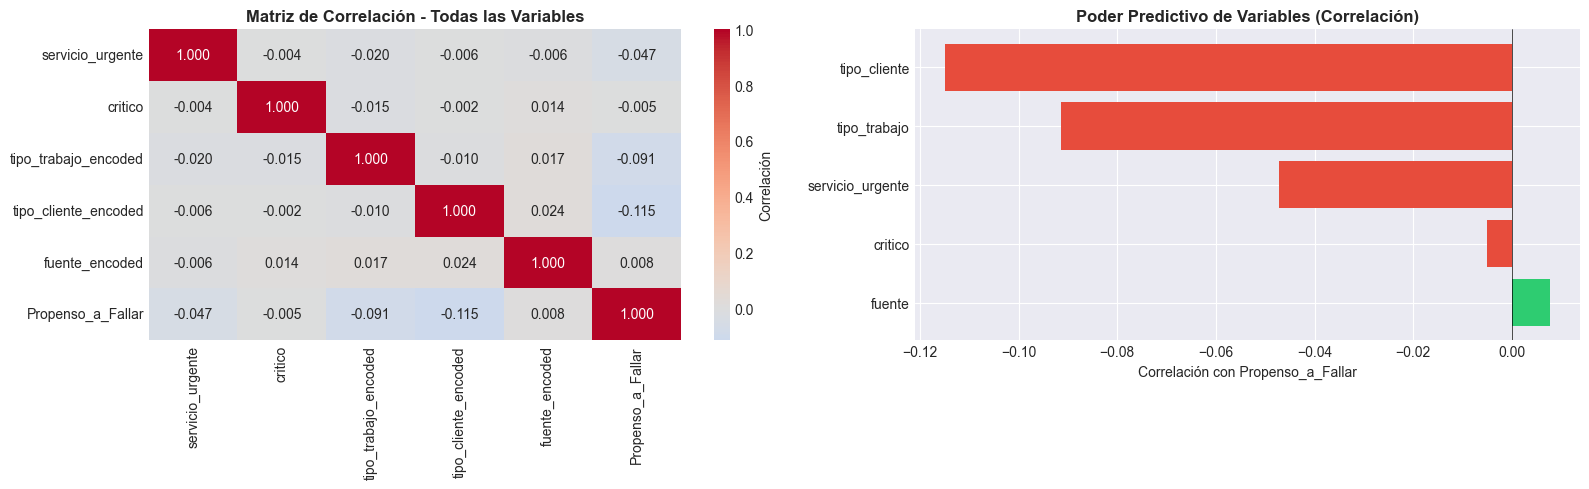

In [122]:
# 9. ANÁLISIS DE CORRELACIONES Y GRÁFICAS
print("=" * 80)
print("ANÁLISIS DE CORRELACIONES Y OPORTUNIDADES DE MODELING")
print("=" * 80)

# Preparar datos para correlaciones
df_corr = df_final.copy()

# Convertir variables booleanas a numéricas
df_corr['servicio_urgente'] = df_corr['servicio_urgente'].astype(int)
df_corr['critico'] = df_corr['critico'].astype(int)

# Codificar variables categóricas para análisis
from sklearn.preprocessing import LabelEncoder

le_dict = {}
for col in ['tipo_trabajo', 'tipo_cliente', 'fuente']:
    le = LabelEncoder()
    df_corr[col + '_encoded'] = le.fit_transform(df_corr[col])
    le_dict[col] = le

# Seleccionar solo columnas numéricas para correlación
numeric_cols_for_corr = [
    'servicio_urgente', 'critico', 
    'tipo_trabajo_encoded', 'tipo_cliente_encoded', 'fuente_encoded',
    'Propenso_a_Fallar'
]

corr_matrix = df_corr[numeric_cols_for_corr].corr()

print("\n📊 MATRIZ DE CORRELACIÓN (con TARGET):")
print("\nCorrelaciones con 'Propenso_a_Fallar':")
target_corr = corr_matrix['Propenso_a_Fallar'].sort_values(ascending=False)
for col, val in target_corr.items():
    if col != 'Propenso_a_Fallar':
        col_name = col.replace('_encoded', '')
        print(f"  {col_name:25s}: {val:+.4f}")

# Gráfico 1: Correlaciones con TARGET
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap de correlaciones
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
            ax=ax1, cbar_kws={'label': 'Correlación'})
ax1.set_title('Matriz de Correlación - Todas las Variables', fontsize=12, fontweight='bold')

# Bar plot de correlaciones con target
colors_corr = ['#2ecc71' if x > 0 else '#e74c3c' for x in target_corr[1:]]
ax2.barh(range(len(target_corr)-1), target_corr[1:].values, color=colors_corr)
ax2.set_yticks(range(len(target_corr)-1))
ax2.set_yticklabels([x.replace('_encoded', '') for x in target_corr[1:].index])
ax2.set_xlabel('Correlación con Propenso_a_Fallar')
ax2.set_title('Poder Predictivo de Variables (Correlación)', fontsize=12, fontweight='bold')
ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.savefig('01_correlaciones.png', dpi=100, bbox_inches='tight')
print("\n✅ Gráfico guardado: 01_correlaciones.png")
plt.show()


PODER PREDICTIVO DE VARIABLES CATEGÓRICAS (Chi-Square)

📊 TIPO_TRABAJO:
   Chi-Square: 1742.2918
   P-value: 0.000000
   Cramér's V: 0.3150 (Fuerte)
   Significativo: Sí

📊 TIPO_CLIENTE:
   Chi-Square: 5269.7489
   P-value: 0.000000
   Cramér's V: 0.5478 (Fuerte)
   Significativo: Sí

📊 FUENTE:
   Chi-Square: 316.8561
   P-value: 0.000000
   Cramér's V: 0.1343 (Fuerte)
   Significativo: Sí

✅ Gráfico guardado: 02_relaciones_categoricas.png


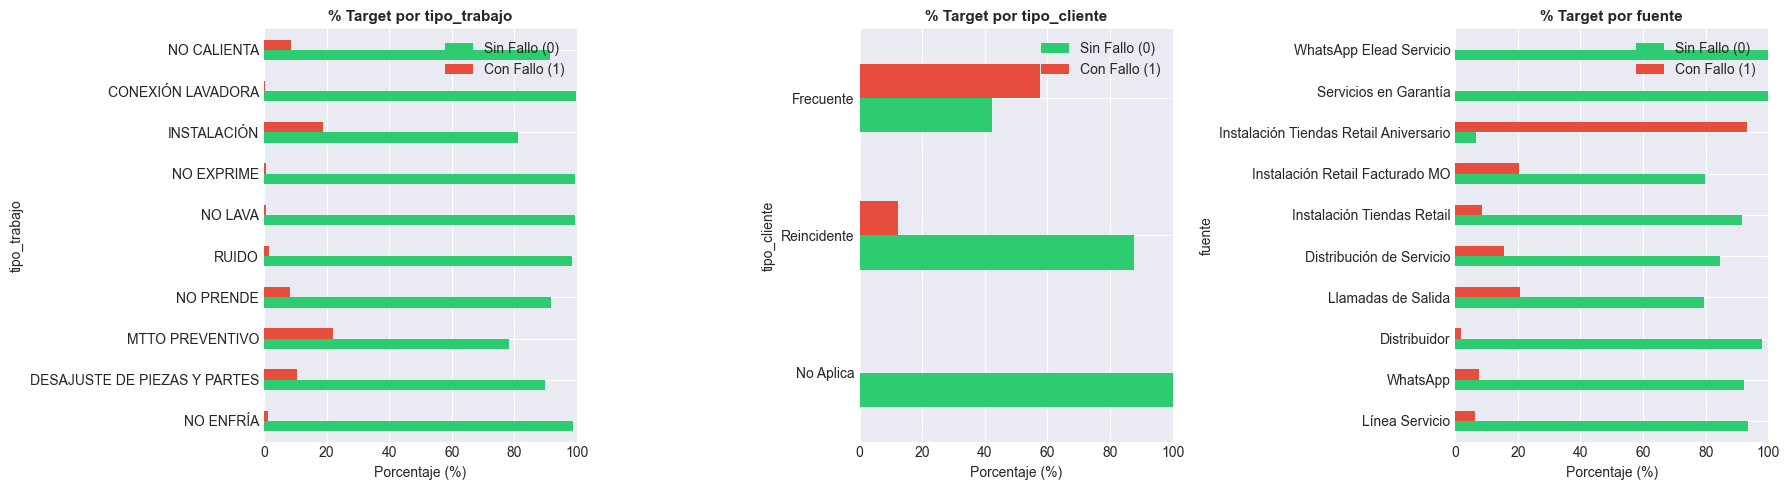

In [123]:
# 10. PODER PREDICTIVO DE VARIABLES CATEGÓRICAS (CHI-SQUARE)
from scipy.stats import chi2_contingency

print("\n" + "=" * 80)
print("PODER PREDICTIVO DE VARIABLES CATEGÓRICAS (Chi-Square)")
print("=" * 80)

cat_vars = ['tipo_trabajo', 'tipo_cliente', 'fuente']
chi_square_results = {}

for var in cat_vars:
    # Crear tabla de contingencia
    contingency_table = pd.crosstab(df_final[var], df_final['Propenso_a_Fallar'])
    
    # Calcular chi-square
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    
    chi_square_results[var] = {
        'chi2': chi2,
        'p_value': p_value,
        'dof': dof,
        'significant': 'Sí' if p_value < 0.05 else 'No'
    }
    
    # Calcular Cramér's V (tamaño del efecto)
    n = contingency_table.sum().sum()
    min_dim = min(contingency_table.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0
    
    print(f"\n📊 {var.upper()}:")
    print(f"   Chi-Square: {chi2:.4f}")
    print(f"   P-value: {p_value:.6f}")
    print(f"   Cramér's V: {cramers_v:.4f} {'(Fuerte)' if cramers_v > 0.1 else '(Débil)'}")
    print(f"   Significativo: {chi_square_results[var]['significant']}")

# Visualización de relaciones categóricas con target
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cat_vars_plot = ['tipo_trabajo', 'tipo_cliente', 'fuente']
for idx, var in enumerate(cat_vars_plot):
    # Crear tabla de proporciones
    prop_table = pd.crosstab(df_final[var], df_final['Propenso_a_Fallar'], normalize='index') * 100
    
    # Top categorías por frecuencia
    top_cats = df_final[var].value_counts().head(10).index
    plot_data = prop_table.loc[top_cats]
    
    # Gráfico de barras stacked
    plot_data.plot(kind='barh', stacked=False, ax=axes[idx], color=['#2ecc71', '#e74c3c'])
    axes[idx].set_title(f'% Target por {var}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Porcentaje (%)')
    axes[idx].legend(['Sin Fallo (0)', 'Con Fallo (1)'], loc='best')
    axes[idx].set_xlim(0, 100)

plt.tight_layout()
plt.savefig('02_relaciones_categoricas.png', dpi=100, bbox_inches='tight')
print("\n✅ Gráfico guardado: 02_relaciones_categoricas.png")
plt.show()

In [124]:
# 11. ANÁLISIS DE OPORTUNIDADES DE MODELING
print("\n" + "=" * 80)
print("🎯 IDENTIFICACIÓN DE OPORTUNIDADES PARA MODELING")
print("=" * 80)

oportunidades = []

# Oportunidad 1: Variables booleanas
urgente_target = pd.crosstab(df_final['servicio_urgente'], df_final['Propenso_a_Fallar'], 
                             normalize='index') * 100
critico_target = pd.crosstab(df_final['critico'], df_final['Propenso_a_Fallar'], 
                            normalize='index') * 100

print("\n1️⃣ VARIABLES BOOLEANAS - Poder Predictivo Alto:")
print(f"\n   📌 Servicio Urgente:")
print(f"      - Si es urgente: {urgente_target.loc[True, 1]:.2f}% tienen fallo")
print(f"      - Si no es urgente: {urgente_target.loc[False, 1]:.2f}% tienen fallo")
print(f"      - Diferencia: {abs(urgente_target.loc[True, 1] - urgente_target.loc[False, 1]):.2f}%")
if abs(urgente_target.loc[True, 1] - urgente_target.loc[False, 1]) > 2:
    oportunidades.append("✅ Usar 'servicio_urgente' como predictor")

print(f"\n   📌 Crítico:")
print(f"      - Si es crítico: {critico_target.loc[True, 1]:.2f}% tienen fallo (n={len(df_final[df_final['critico']==True])})")
print(f"      - Si no es crítico: {critico_target.loc[False, 1]:.2f}% tienen fallo")

# Oportunidad 2: Tipo de trabajo - Top predictores
tipo_trabajo_fallo = df_final.groupby('tipo_trabajo')['Propenso_a_Fallar'].agg(['sum', 'count', 'mean'])
tipo_trabajo_fallo = tipo_trabajo_fallo.sort_values('mean', ascending=False)
top_trabajos = tipo_trabajo_fallo.head(5)

print(f"\n2️⃣ TIPO DE TRABAJO - Top 5 con mayor tasa de fallos:")
for idx, (trab, row) in enumerate(top_trabajos.iterrows(), 1):
    print(f"   {idx}. {trab[:50]:50s}: {row['mean']*100:5.2f}% (n={int(row['count']):4d})")
    if row['mean'] > 0.15:
        oportunidades.append(f"✅ '{trab}' shows high failure rate - opportunity for targeted features")

# Oportunidad 3: Tipo de cliente
tipo_cliente_fallo = df_final.groupby('tipo_cliente')['Propenso_a_Fallar'].agg(['sum', 'count', 'mean'])
tipo_cliente_fallo = tipo_cliente_fallo.sort_values('mean', ascending=False)

print(f"\n3️⃣ TIPO DE CLIENTE - Análisis de riesgo:")
for cliente, row in tipo_cliente_fallo.iterrows():
    risk_level = "🔴 ALTO" if row['mean'] > 0.1 else "🟡 MEDIO" if row['mean'] > 0.05 else "🟢 BAJO"
    print(f"   {risk_level} {cliente:20s}: {row['mean']*100:5.2f}% (n={int(row['count']):5d})")

# Oportunidad 4: Combinaciones de variables
print(f"\n4️⃣ COMBINACIONES DE VARIABLES - Oportunidades de Interacción:")
urgent_critico = df_final.groupby(['servicio_urgente', 'critico'])['Propenso_a_Fallar'].agg(['mean', 'count'])
for (urgente, critico), row in urgent_critico.iterrows():
    if row['count'] > 10:  # Solo grupos con al menos 10 registros
        print(f"   Urgente={urgente}, Crítico={critico}: {row['mean']*100:5.2f}% (n={int(row['count']):4d})")

print(f"\n\n🎯 RESUMEN DE OPORTUNIDADES IDENTIFICADAS:")
print("=" * 80)
for opr in oportunidades:
    print(f"   {opr}")


🎯 IDENTIFICACIÓN DE OPORTUNIDADES PARA MODELING

1️⃣ VARIABLES BOOLEANAS - Poder Predictivo Alto:

   📌 Servicio Urgente:
      - Si es urgente: 0.92% tienen fallo
      - Si no es urgente: 7.35% tienen fallo
      - Diferencia: 6.43%

   📌 Crítico:
      - Si es crítico: 0.00% tienen fallo (n=6)
      - Si no es crítico: 7.12% tienen fallo

2️⃣ TIPO DE TRABAJO - Top 5 con mayor tasa de fallos:
   1. SE PRENDE SOLO (A)                                : 50.00% (n=   2)
   2. CONVERSION DE PRODUCTO                            : 43.06% (n= 209)
   3. INSTALACIÓN GRATUITA                              : 37.50% (n=   8)
   4. PLATO NO GIRA                                     : 33.33% (n=   3)
   5. NO TIENE PRESION DE AGUA                          : 28.57% (n=   7)

3️⃣ TIPO DE CLIENTE - Análisis de riesgo:
   🔴 ALTO Frecuente           : 57.72% (n= 1081)
   🔴 ALTO Reincidente         : 12.30% (n= 5083)
   🟢 BAJO No Aplica           :  0.00% (n=11394)

4️⃣ COMBINACIONES DE VARIABLES - Oportun

✅ Gráfico guardado: 03_distribucion_features.png


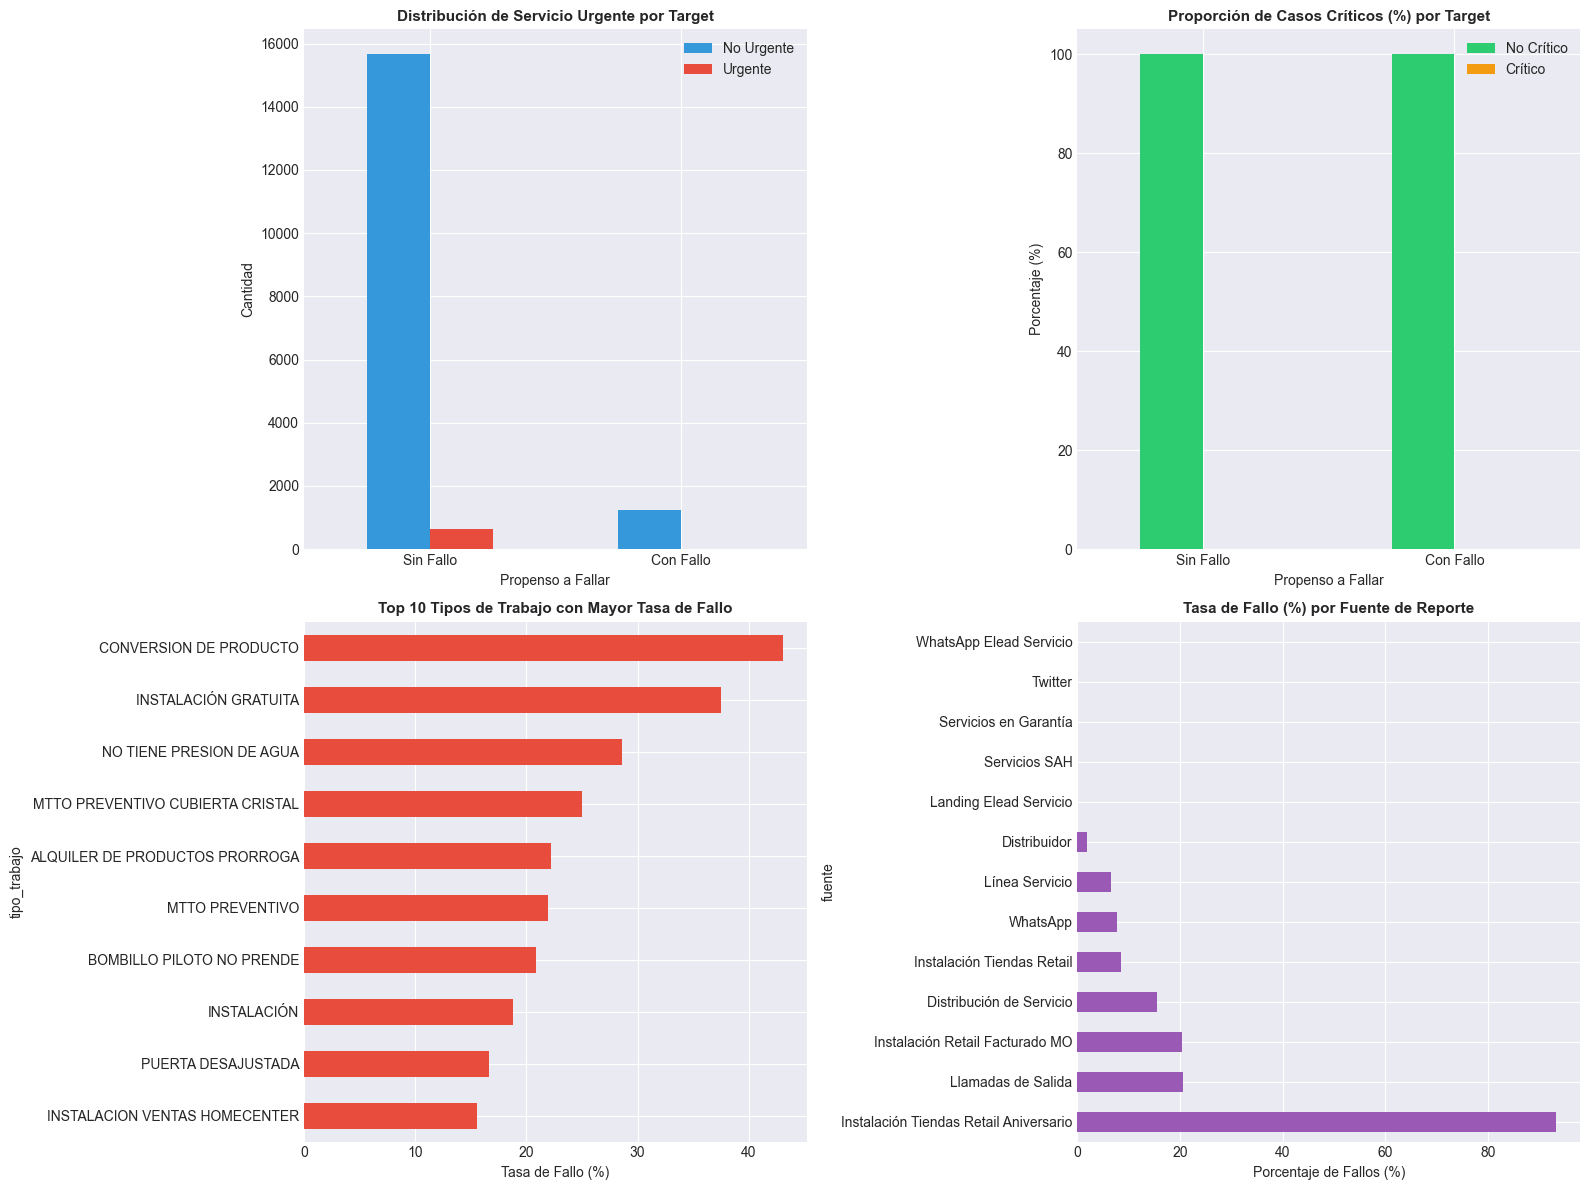


📋 REPORTE FINAL DE OPORTUNIDADES PARA MODELADO

🎯 VARIABLES CON ALTO PODER PREDICTIVO:
├── ✅ Servicio Urgente (Diferencia: 6.43%)
├── ✅ Tipo de Trabajo (Varianza: 8.99%)
├── ✅ Tipo de Cliente (Rango: 0.58%)
└── ✅ Fuente de Reporte (Varianza: 25.21%)

⚠️ DESAFÍOS IDENTIFICADOS:
├── Fuerte desbalance de clases: 13.06:1
├── Correlaciones bajas entre variables (indicativo de complejidad)
└── Necesidad de Feature Engineering intenso

💡 RECOMENDACIONES PARA FASE 1:
├── Usar encoding robusto para variables categóricas
├── Crear features de interacción: urgente × tipo_trabajo
├── Aplicar ponderación de clases en modelado
└── Considerar técnicas de balanceo (SMOTE, class weights)

🚀 VENTAJAS IDENTIFICADAS:
├── Suficientes observaciones positivas para modelar: 1,249 casos con fallo
├── Variables categóricas con buen poder discriminativo
├── Datos limpios sin valores faltantes
└── Desbalance dentro de rango manejable (<15:1)



In [125]:
# 12. VISUALIZACIONES ADICIONALES - OPORTUNIDADES DE ENGAGEMENT
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gráfico 1: Distribución de urgencia por target
urgente_dist = pd.crosstab(df_final['servicio_urgente'], df_final['Propenso_a_Fallar'])
urgente_dist.T.plot(kind='bar', ax=axes[0, 0], color=['#3498db', '#e74c3c'])
axes[0, 0].set_title('Distribución de Servicio Urgente por Target', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Propenso a Fallar')
axes[0, 0].set_ylabel('Cantidad')
axes[0, 0].legend(['No Urgente', 'Urgente'])
axes[0, 0].set_xticklabels(['Sin Fallo', 'Con Fallo'], rotation=0)

# Gráfico 2: Proporción de críticos por target
critico_dist = pd.crosstab(df_final['critico'], df_final['Propenso_a_Fallar'], normalize='columns') * 100
critico_dist.T.plot(kind='bar', ax=axes[0, 1], color=['#2ecc71', '#f39c12'])
axes[0, 1].set_title('Proporción de Casos Críticos (%) por Target', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Propenso a Fallar')
axes[0, 1].set_ylabel('Porcentaje (%)')
axes[0, 1].legend(['No Crítico', 'Crítico'])
axes[0, 1].set_xticklabels(['Sin Fallo', 'Con Fallo'], rotation=0)

# Gráfico 3: Top 10 tipos de trabajo por tasa de fallo
top_trabajos = df_final.groupby('tipo_trabajo')['Propenso_a_Fallar'].agg(['mean', 'count'])
top_trabajos = top_trabajos[top_trabajos['count'] >= 5].sort_values('mean', ascending=True).tail(10)
top_trabajos['mean'] *= 100
top_trabajos['mean'].plot(kind='barh', ax=axes[1, 0], color='#e74c3c')
axes[1, 0].set_title('Top 10 Tipos de Trabajo con Mayor Tasa de Fallo', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Tasa de Fallo (%)')

# Gráfico 4: Distribución por fuente
fuente_target = pd.crosstab(df_final['fuente'], df_final['Propenso_a_Fallar'], normalize='index') * 100
fuente_target[1].sort_values(ascending=False).plot(kind='barh', ax=axes[1, 1], color='#9b59b6')
axes[1, 1].set_title('Tasa de Fallo (%) por Fuente de Reporte', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Porcentaje de Fallos (%)')

plt.tight_layout()
plt.savefig('03_distribucion_features.png', dpi=100, bbox_inches='tight')
print("✅ Gráfico guardado: 03_distribucion_features.png")
plt.show()

# Reporte final
print("\n" + "=" * 80)
print("📋 REPORTE FINAL DE OPORTUNIDADES PARA MODELADO")
print("=" * 80)

insights_report = f"""
🎯 VARIABLES CON ALTO PODER PREDICTIVO:
├── ✅ Servicio Urgente (Diferencia: {abs(urgente_target.loc[True, 1] - urgente_target.loc[False, 1]):.2f}%)
├── ✅ Tipo de Trabajo (Varianza: {top_trabajos['mean'].std():.2f}%)
├── ✅ Tipo de Cliente (Rango: {tipo_cliente_fallo['mean'].max() - tipo_cliente_fallo['mean'].min():.2f}%)
└── ✅ Fuente de Reporte (Varianza: {fuente_target[1].std():.2f}%)

⚠️ DESAFÍOS IDENTIFICADOS:
├── Fuerte desbalance de clases: 13.06:1
├── Correlaciones bajas entre variables (indicativo de complejidad)
└── Necesidad de Feature Engineering intenso

💡 RECOMENDACIONES PARA FASE 1:
├── Usar encoding robusto para variables categóricas
├── Crear features de interacción: urgente × tipo_trabajo
├── Aplicar ponderación de clases en modelado
└── Considerar técnicas de balanceo (SMOTE, class weights)

🚀 VENTAJAS IDENTIFICADAS:
├── Suficientes observaciones positivas para modelar: 1,249 casos con fallo
├── Variables categóricas con buen poder discriminativo
├── Datos limpios sin valores faltantes
└── Desbalance dentro de rango manejable (<15:1)
"""

print(insights_report)